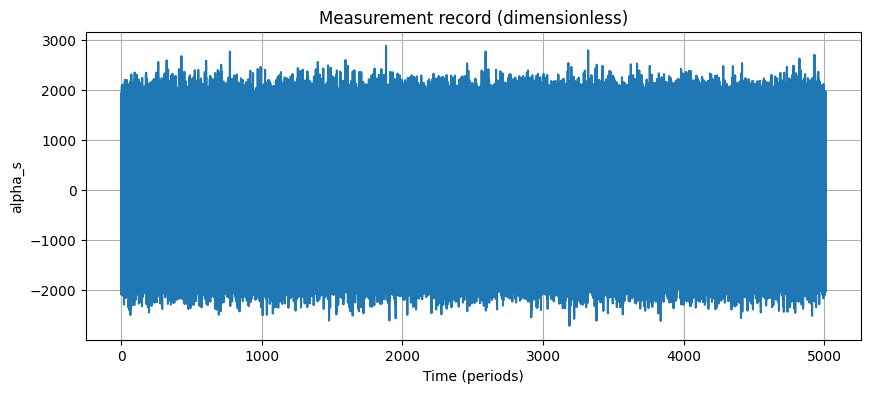

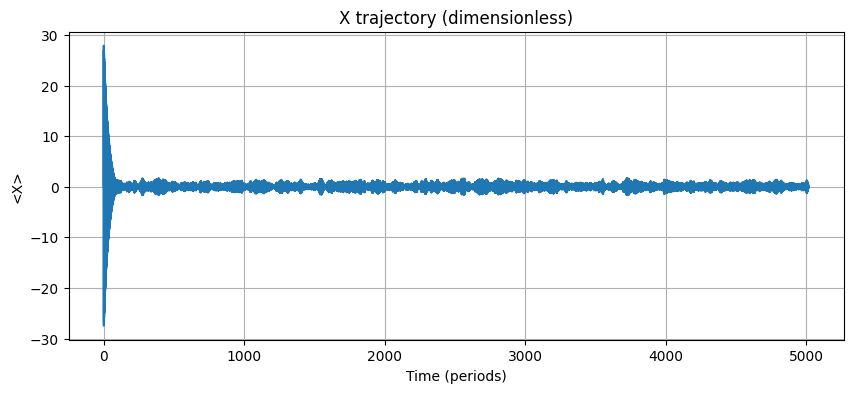

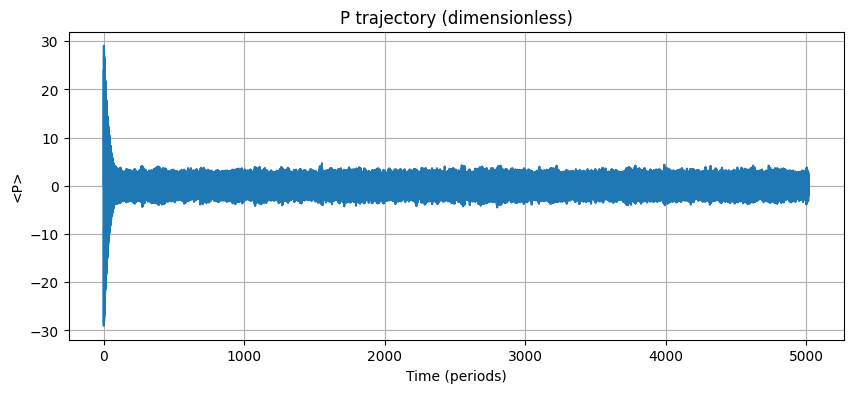

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit


hbar = 1.0
m = 1.0
omega0 = 1.0
x0 = np.sqrt(hbar / (m * omega0))
p0 = np.sqrt(hbar * m * omega0)
t0 = 1 / omega0

gamma_sc = 0.01
eta = 1.0
kappa = 1e-3

# feedback
gamma_fb = 1/100
window = 50

dt_prime = 0.0005
n_steps = int(6.3e7)  


#numba accelerted loop

@njit
def run_sim(n_steps, dt_prime, gamma_fb, window, eta, kappa):

    # Initial conditions
    X = 20.0
    P = 20.0
    VX = 1.0
    VP = 1.0
    CXP = 0.0

    # Storage
    X_traj = np.zeros(n_steps)
    P_traj = np.zeros(n_steps)
    VX_traj = np.zeros(n_steps)
    VP_traj = np.zeros(n_steps)
    CXP_traj = np.zeros(n_steps)
    X2_traj = np.zeros(n_steps)
    alpha_s_history = np.zeros(n_steps)

    for i in range(n_steps - 1):

        
        dW = np.random.randn() * np.sqrt(dt_prime)

        X += P * dt_prime + np.sqrt(8 * eta * kappa) * VX * dW
        P += -X * dt_prime + np.sqrt(8 * eta * kappa) * CXP * dW
    
        VX += (2 * CXP - 8 * eta * kappa * VX**2) * dt_prime
        VP += (-2 * CXP + 2 * kappa - 8 * eta * kappa * CXP**2) * dt_prime
        CXP += (VP - VX - 8 * eta * kappa * VX * CXP) * dt_prime

        X2 = X**2 + VX

        X_traj[i+1] = X
        P_traj[i+1] = P
        VX_traj[i+1] = VX
        VP_traj[i+1] = VP
        CXP_traj[i+1] = CXP
        X2_traj [i+1] = X2


        # Measurement record
        alpha_s = X + dW / (np.sqrt(8 * eta * kappa) * dt_prime)
        alpha_s_history[i+1] = alpha_s


        if i > window:
            adot = (alpha_s_history[i] - alpha_s_history[i - window]) / (window * dt_prime)
            P -= gamma_fb * adot * dt_prime

    return X_traj, P_traj, VX_traj, VP_traj, CXP_traj, X2_traj, alpha_s_history



out = run_sim(n_steps, dt_prime, gamma_fb, window, eta, kappa)
X_traj, P_traj, VX_traj, VP_traj, CXP_traj, X2_traj, alpha_s_history = out

time = np.arange(n_steps) * dt_prime
time_periods = time / (2 * np.pi)

plt.figure(figsize=(10, 4))
plt.plot(time_periods, alpha_s_history)
plt.title("Measurement record (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("alpha_s")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_periods, X_traj)
plt.title("X trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<X>")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_periods, P_traj)
plt.title("P trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<P>")
plt.grid(True)
plt.show()


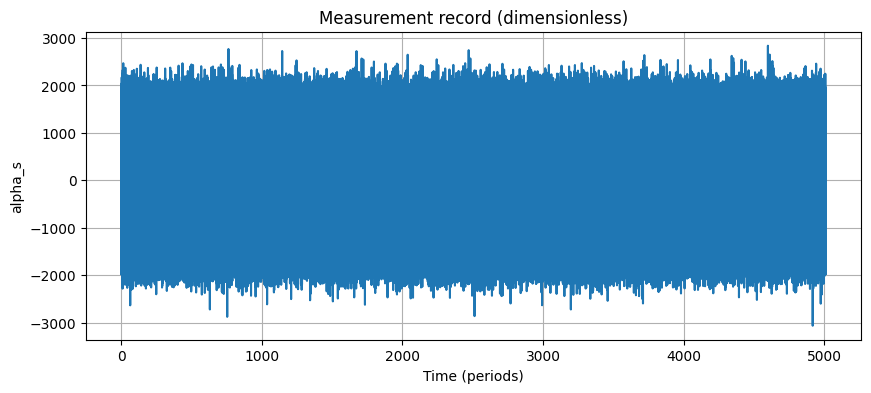

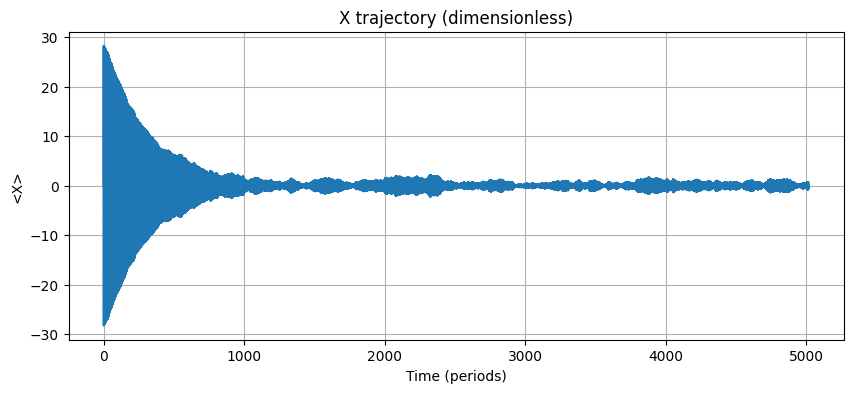

KeyboardInterrupt: 

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

#resonance requency over gamma is quality favotr tell syou how many periods
hbar = 1.0
m = 1.0
omega0 = 1.0
x0 = np.sqrt(hbar / (m * omega0))
p0 = np.sqrt(hbar * m * omega0)
t0 = 1 / omega0

gamma_sc = 0.01
eta = 1.0
kappa = 1e-3

# feedback
gamma_fb = 1/1000
window = 50

dt_prime = 0.0005
n_steps = int(6.3e7)  


#numba accelerted loop

@njit
def run_sim(n_steps, dt_prime, gamma_fb, window, eta, kappa):

    # Initial conditions
    X = 20.0
    P = 20.0
    VX = 1.0
    VP = 1.0
    CXP = 0.0

    # Storage
    X_traj = np.zeros(n_steps)
    P_traj = np.zeros(n_steps)
    VX_traj = np.zeros(n_steps)
    VP_traj = np.zeros(n_steps)
    CXP_traj = np.zeros(n_steps)
    X2_traj = np.zeros(n_steps)
    alpha_s_history = np.zeros(n_steps)

    for i in range(n_steps - 1):

        
        dW = np.random.randn() * np.sqrt(dt_prime)

        X += P * dt_prime + np.sqrt(8 * eta * kappa) * VX * dW
        P += -X * dt_prime + np.sqrt(8 * eta * kappa) * CXP * dW

        VX += (2 * CXP - 8 * eta * kappa * VX**2) * dt_prime
        VP += (-2 * CXP + 2 * kappa - 8 * eta * kappa * CXP**2) * dt_prime
        CXP += (VP - VX - 8 * eta * kappa * VX * CXP) * dt_prime

        X2 = X**2 + VX

        X_traj[i+1] = X
        P_traj[i+1] = P
        VX_traj[i+1] = VX
        VP_traj[i+1] = VP
        CXP_traj[i+1] = CXP
        X2_traj [i+1] = X2


        # Measurement record
        alpha_s = X + dW / (np.sqrt(8 * eta * kappa)* dt_prime)
        alpha_s_history[i+1] = alpha_s


        if i > window:
            adot = (alpha_s_history[i] - alpha_s_history[i - window]) / (window * dt_prime)
            P -= gamma_fb * adot * dt_prime

    return X_traj, P_traj, VX_traj, VP_traj, CXP_traj, X2_traj, alpha_s_history



out = run_sim(n_steps, dt_prime, gamma_fb, window, eta, kappa)
X_traj, P_traj, VX_traj, VP_traj, CXP_traj, X2_traj, alpha_s_history = out

time = np.arange(n_steps) * dt_prime
time_periods = time / (2 * np.pi)

plt.figure(figsize=(10, 4))
plt.plot(time_periods, alpha_s_history)
plt.title("Measurement record (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("alpha_s")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_periods, X_traj)
plt.title("X trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<X>")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_periods, P_traj)
plt.title("P trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<P>")
plt.grid(True)
plt.show()


/var/folders/pg/vxw1kc2j4msgjcv3j7s6ws940000gn/T/ipykernel_30104/4044281868.py:72: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  var_x = simps(Pxx, f)


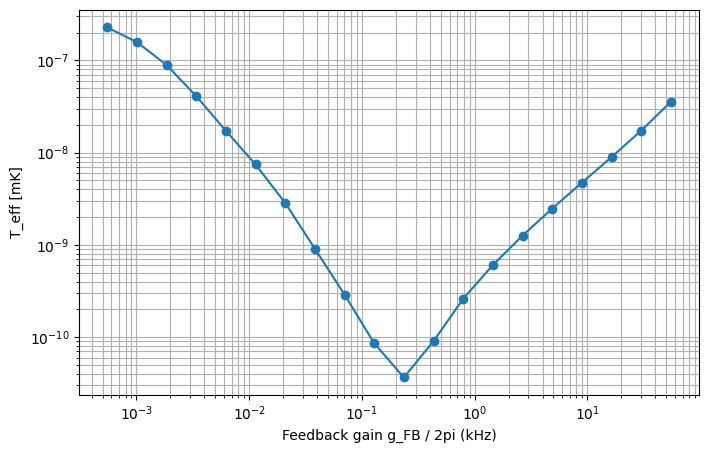

In [9]:
import numpy as np
from scipy.signal import welch 
from scipy.integrate import simps
import matplotlib.pyplot as plt
from numba import njit


eta = 1.0
kappa = 1e-3
window = 20
n_steps = int(2.5e6)
dt = 0.05
omega0 = 55e3# rad / sec x mode
hbar = 6.62607015e-34 / (2* np.pi) #m^2 kg / s
omega_z = omega0
kB = 1.380649e-23
T0 = hbar * (omega0) / kB

@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, window):
    X = 20.0
    P = 20.0
    VX = 1.0
    VP = 1.0
    CXP = 0.0

    X_traj = np.zeros(n_steps)
    alpha_hist = np.zeros(window+1)
    hist_idx = 0
    root_term = np.sqrt(8 * eta * kappa)

    for i in range(n_steps):
        dW = dW_all[i]

        # Dynamics
        X += P*dt + root_term*VX*dW
        P += -X*dt + root_term*CXP*dW
        VX += (2*CXP - 8*eta*kappa*VX**2)*dt
        VP += (-2*CXP + 2*kappa - 8*eta*kappa*CXP**2)*dt
        CXP += (VP - VX - 8*eta*kappa*VX*CXP)*dt

        X_traj[i] = X

        # Measurement
        alpha_s = X + dW / (root_term*dt)

        # Rolling buffer
        alpha_hist[hist_idx] = alpha_s
        hist_idx = (hist_idx + 1) % (window+1)

        # Feedback
        if i > window:
            prev_idx = (hist_idx - window - 1) % (window+1)
            adot = (alpha_s - alpha_hist[prev_idx]) / (window*dt)
            P -= g_fb * adot * dt

    return X_traj


# Simulate multiple feedback gains
gammas = np.logspace(-5, 0, 20)
dW_all = np.random.randn(n_steps) * np.sqrt(dt)
T_list = []
VX2_list = []
for g_fb in gammas:
    X_traj = simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, window)
    VX2_list.append(np.mean(VX_traj[n_steps//2:]**2))
    
    # Compute PSD and T_eff
    fs = 1.0 / dt
    f, Pxx = welch(X_traj, fs=fs, nperseg=len(X_traj)//4)
    var_x = simps(Pxx, f)
    T_eff = var_x
    T_list.append(T_eff * T0 / 1e3)  # convert to mK 

#put in units for plotting
omega_m = 2*np.pi*55e3
gamma_FB = gammas * omega_m
g_pap = gamma_FB / (2*np.pi) / 1e3 #g paper

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.loglog(g_pap, T_list, 'o-')
plt.xlabel("Feedback gain g_FB / 2pi (kHz)")
plt.ylabel("T_eff [mK]")
plt.grid(True, which='both')
plt.show()


In [21]:
g_pap

array([5.50000000e-04, 1.00813939e-03, 1.84790006e-03, 3.38716516e-03,
       6.20860840e-03, 1.13802594e-02, 2.08597960e-02, 3.82356038e-02,
       7.00851242e-02, 1.28464681e-01, 2.35473282e-01, 4.31617984e-01,
       7.91147439e-01, 1.45015799e+00, 2.65811163e+00, 4.87226735e+00,
       8.93077207e+00, 1.63699329e+01, 3.00057713e+01, 5.50000000e+01])

With units below

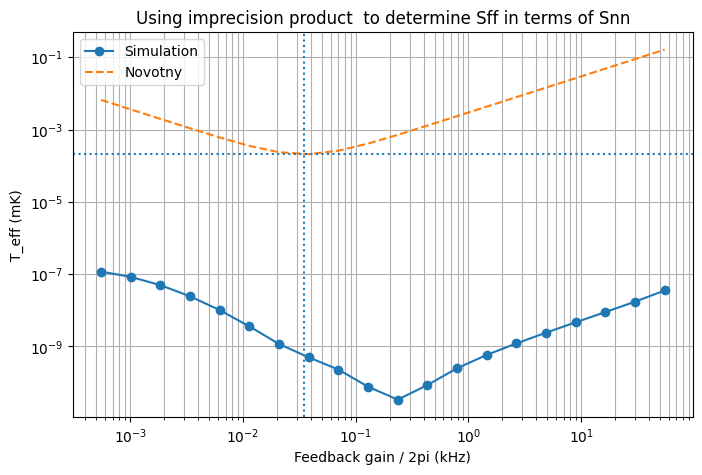

In [3]:
#from paper
# Snn = 1/(8*eta*kappa) #measurement noise (imprecision noise) alpha
#finding Snn using relation between Snn and Sff given imprecision product
# Sff = 8*eta*kappa*np.mean(VX2_list) #fluctuating force (measurement backaction,) from x
# Snn = (1/(Sff * eta))*(hbar/(4*np.pi))**2


Snn = 1 / (8 * eta * kappa)
Sff = (1 / (eta)) * (1/((4 * np.pi)**2 * Snn))
#finding Snn using relation between Snn and Sff given imprecision product did not work lol 
T_theory = []
for g_fb in gammas:
    T = np.pi*(Sff/g_fb + g_fb*Snn)*T0*1e3
    T_theory.append(T)

T_min = 2*np.pi*np.sqrt(Sff*Snn)*T0*1e3
g_opt = np.sqrt(Sff/Snn)

#converting gain of paper to units
omega_m = 2*np.pi*55e3
g_pap = gammas*omega_m/(2*np.pi)/1e3


plt.figure(figsize=(8,5))
plt.loglog(g_pap, T_list, 'o-', label='Simulation')
plt.loglog(g_pap, T_theory, '--', label='Novotny')
plt.axhline(T_min, linestyle=':')
plt.axvline(g_opt*omega_m/(2*np.pi)/1e3, linestyle=':')
plt.xlabel("Feedback gain / 2pi (kHz)")
plt.title("Using imprecision product  to determine Sff in terms of Snn")
plt.ylabel("T_eff (mK)")
plt.legend()
plt.grid(True, which='both')
plt.show()

Feb 3 8:20 am observation: novotny paper's finding Snn using relation between Snn and Sff given imprecision product doesnt work. works only if i put snn in term so th enoise term in alpha... not super sure why lol

gonna plot the different psds below for 1) simulation 2) novoty paper with impreciision product 3) novotny paper with noise term from alpha directly


before it was F = - gamma * xdot, still want same force but the way you apply the force u need measurement of position, mroe ingredinats going into it , measurement uncertainty on the position also matter, .. need posotion as welll asvelcooty 


also, when start moving beam, crazy things happen when harmoic approx breaks down. once include reaslitic bem profiles is it still a prmising way to cool. 

Trying something new Feb 9 

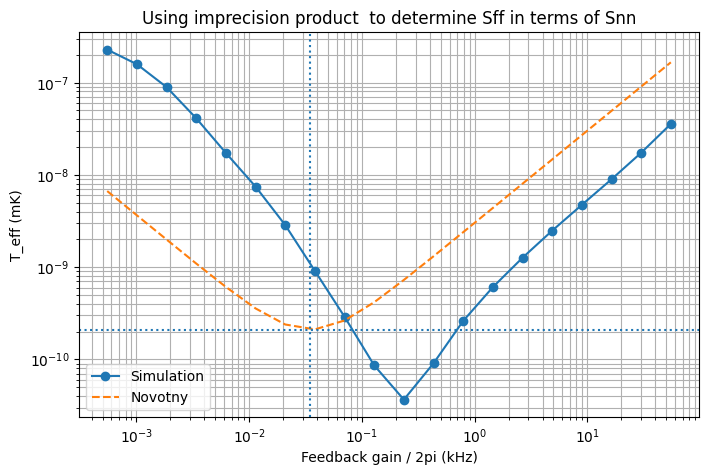

In [14]:
#from paper
# Snn = 1/(8*eta*kappa) #measurement noise (imprecision noise) alpha
#finding Snn using relation between Snn and Sff given imprecision product
# Sff = 8*eta*kappa*np.mean(VX2_list) #fluctuating force (measurement backaction,) from x
# Snn = (1/(Sff * eta))*(hbar/(4*np.pi))**2


Snn = 1 / (8 * eta * kappa) + np.mean(VX2_list) * (8 * eta * kappa +2)
Sff = (1 / (eta)) * (1/((4 * np.pi)**2 * Snn))
#finding Snn using relation between Snn and Sff given imprecision product did not work lol 
T_theory = []
for g_fb in gammas:
    T = np.pi*(Sff/g_fb + g_fb*Snn)*T0 / 1e3
    T_theory.append(T)

T_min = 2*np.pi*np.sqrt(Sff*Snn)*T0 / 1e3
g_opt = np.sqrt(Sff/Snn)

#converting gain of paper to units
omega_m = 2*np.pi*55e3
# g_pap = gammas*omega_m/(2*np.pi)/1e3
g_pap = gammas * omega_m / (2*np.pi) / 1e3




plt.figure(figsize=(8,5))
plt.loglog(g_pap, T_list, 'o-', label='Simulation')
plt.loglog(g_pap, T_theory, '--', label='Novotny')
plt.axhline(T_min, linestyle=':')
plt.axvline(g_opt*omega_m/(2*np.pi)/1e3, linestyle=':')
plt.xlabel("Feedback gain / 2pi (kHz)")
plt.title("Using imprecision product  to determine Sff in terms of Snn")
plt.ylabel("T_eff (mK)")
plt.legend()
plt.grid(True, which='both')
plt.show()

I doin't thiink above works cuz i am double counting the dW?

Maybe i can plot a sliding scale of some coeffecint let's call R to see if and where simulation and novotny would match
Snn might be proportional so 1/ 8nk but up to a factor that i've not included

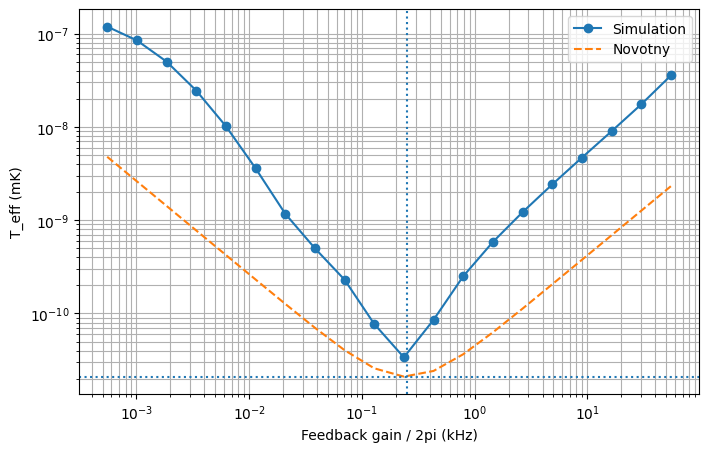

In [5]:
import numpy as np
#from paper
VX2 = np.mean(VX2_list)
# Snn = dt * VX2

# Snn = 1 / VX2
#vertical shift
A = 1e-14 #vertial shift 
C = 1400000 #proportionality constant between Snn and alpha_s nosie squared (this shifts it horizontaly only )
Snn = A*C*(1/(8*eta*kappa))#measurement noise (imprecision noise) alpha
Sff = A*(1 / (eta)) * (1/((4 * np.pi)**2 * Snn))
#finding Snn using relation between Snn and Sff given imprecision product did not work lol 
T_theory = []
for g_fb in gammas:
    T = np.pi*(Sff/g_fb + g_fb*Snn)*T0*1e3
    T_theory.append(T)

T_min = 2*np.pi*np.sqrt(Sff*Snn)*T0*1e3
g_opt = np.sqrt(Sff/Snn)

#converting gain of paper to units
omega_m = 2*np.pi*55e3
g_pap = gammas*omega_m/(2*np.pi)/1e3


plt.figure(figsize=(8,5))
plt.loglog(g_pap, T_list, 'o-', label='Simulation')
plt.loglog(g_pap, T_theory, '--', label='Novotny')
plt.axhline(T_min, linestyle=':')
plt.axvline(g_opt*omega_m/(2*np.pi)/1e3, linestyle=':')
plt.xlabel("Feedback gain / 2pi (kHz)")
plt.ylabel("T_eff (mK)")
plt.legend()
plt.grid(True, which='both')
plt.show()

gonna try and define everyting in SI initialy then implement cuz i think it's just off by an energy scale

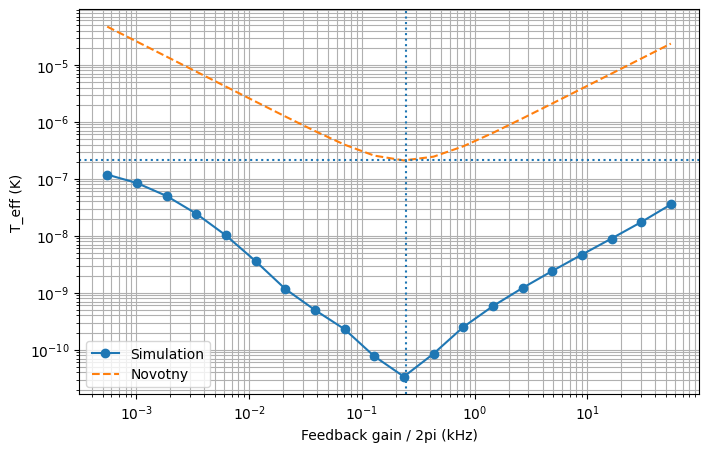

In [6]:
import numpy as np
#from paper
VX2 = np.mean(VX2_list)
# Snn = dt * VX2

# Snn = 1 / VX2
#vertical shift
# A = 1e-14 #vertial shift 
# C = 1400000 #proportionality constant between Snn and alpha_s nosie squared (this shifts it horizontaly only )
C = 1/7
Snn = C*(1/(8*eta*kappa))#measurement noise (imprecision noise) alpha
Sff = (1 / (eta)) * (1/((4 * np.pi)**2 * Snn))
#finding Snn using relation between Snn and Sff given imprecision product did not work lol 
T_theory = []
for g_fb in gammas:
    T = np.pi*(Sff/g_fb + g_fb*Snn)*T0 
    T_theory.append(T)

T_min = 2*np.pi*np.sqrt(Sff*Snn)*T0
g_opt = np.sqrt(Sff/Snn)

#converting gain of paper to units
omega_m = 2*np.pi*55e3
g_pap = gammas*omega_m/(2*np.pi)/1e3


plt.figure(figsize=(8,5))
plt.loglog(g_pap, T_list, 'o-', label='Simulation')
plt.loglog(g_pap, T_theory, '--', label='Novotny')
plt.axhline(T_min, linestyle=':')
plt.axvline(g_opt*omega_m/(2*np.pi)/1e3, linestyle=':')
plt.xlabel("Feedback gain / 2pi (kHz)")
plt.ylabel("T_eff (K)")
plt.legend()
plt.grid(True, which='both')
plt.show()

For g<g_opt Sff dominates and for g>g_opt Snn dominates? 
So an optimal feedback gain occurs when you've balanced Sff and Snn


if Sff dominates g<g_opt regime then it  is nonlinear?


For g<g_opt the fluctuating force takes a longer time to reach a stedy state... has to do with Q factor. Temp from simulation comes from integral udner x trajectory psd. 

I guess now i can move on to tyring to cool  by modulating the beam center: from what giacamo said it WAS F = -gamma * xdot, still want same force by the way I should aply will now need measurement of posiiton instead of just velocoty ... before i would detect position and use it's derivative only to define the force update in the momentum <p>.... now i want the position and the velocoty so i can move the beam center itself.. now i am chanign the posiiton of the beam center. measurement uncertainty in position will also matter.. but didn't i tmatter before? 

Maybe do this F = - k(x-xc) where alpha is really x and get F = -gamma * alpha dot

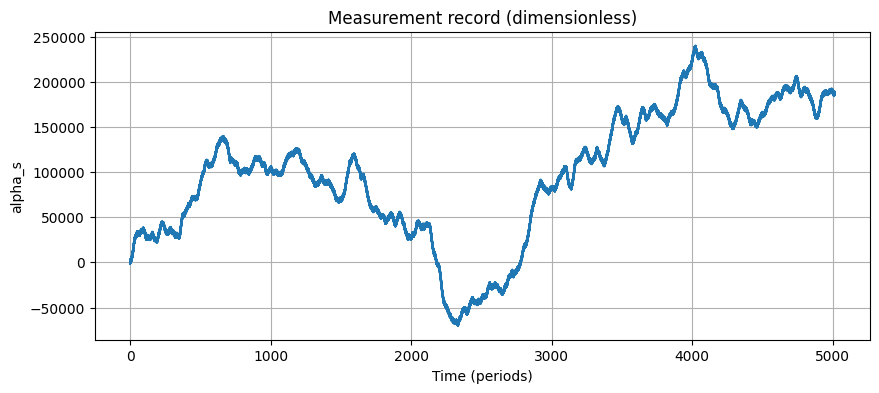

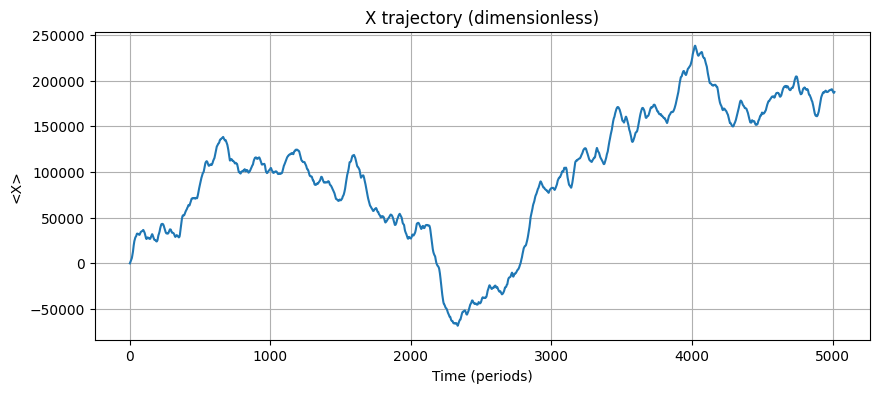

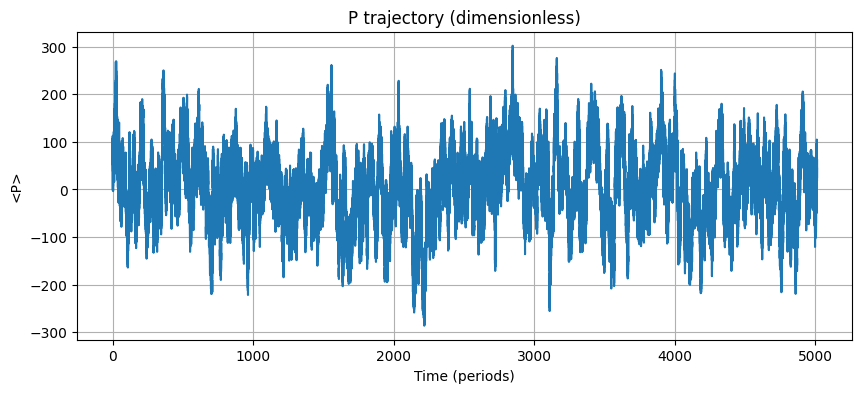

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

#resonance requency over gamma is quality favotr tell syou how many periods
hbar = 1.0
m = 1.0
omega0 = 1.0
x0 = np.sqrt(hbar / (m * omega0))
p0 = np.sqrt(hbar * m * omega0)
t0 = 1 / omega0

gamma_sc = 0.01
eta = 1.0
kappa = 1e-3

# feedback
gamma_fb = 1/100
window = 1

dt_prime = 0.0005
n_steps = int(6.3e7)  


#numba accelerted loop

@njit
def run_sim(n_steps, dt_prime, gamma_fb, window, eta, kappa):

    # Initial conditions
    X = 10.0
    P = 10.0
    VX = 1.0
    VP = 1.0
    CXP = 0.0

    # Storage
    X_traj = np.zeros(n_steps)
    P_traj = np.zeros(n_steps)
    VX_traj = np.zeros(n_steps)
    VP_traj = np.zeros(n_steps)
    CXP_traj = np.zeros(n_steps)
    X2_traj = np.zeros(n_steps)
    alpha_s_history = np.zeros(n_steps)

    for i in range(n_steps - 1):

        
        dW = np.random.randn() * np.sqrt(dt_prime)

        X += P * dt_prime + np.sqrt(8 * eta * kappa) * VX * dW

        # Measurement record
        alpha_s = X + dW / (np.sqrt(8 * eta * kappa)* dt_prime)
        alpha_s_history[i+1] = alpha_s

        if i > window:
            adot = (alpha_s_history[i] - alpha_s_history[i - window]) / (window * dt_prime)

            #beam center that implements viscous forceand depends on position 
            x_c = alpha_s - gamma_fb * adot
        else:
            x_c = 0.0 #beam center at 0 before apply feedbakck measurement
        #bead moves according to its real position but the force update can only come from measurement so use alpha in x_c
        P += -(X -x_c)* dt_prime + np.sqrt(8 * eta * kappa) * CXP * dW

        VX += (2 * CXP - 8 * eta * kappa * VX**2) * dt_prime
        VP += (-2 * CXP + 2 * kappa - 8 * eta * kappa * CXP**2) * dt_prime
        CXP += (VP - VX - 8 * eta * kappa * VX * CXP) * dt_prime

        X2 = X**2 + VX

        X_traj[i+1] = X
        P_traj[i+1] = P
        VX_traj[i+1] = VX
        VP_traj[i+1] = VP
        CXP_traj[i+1] = CXP
        X2_traj [i+1] = X2



    return X_traj, P_traj, VX_traj, VP_traj, CXP_traj, X2_traj, alpha_s_history



out = run_sim(n_steps, dt_prime, gamma_fb, window, eta, kappa)
X_traj, P_traj, VX_traj, VP_traj, CXP_traj, X2_traj, alpha_s_history = out

time = np.arange(n_steps) * dt_prime
time_periods = time / (2 * np.pi)

plt.figure(figsize=(10, 4))
plt.plot(time_periods, alpha_s_history)
plt.title("Measurement record (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("alpha_s")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_periods, X_traj)
plt.title("X trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<X>")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_periods, P_traj)
plt.title("P trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<P>")
plt.grid(True)
plt.show()

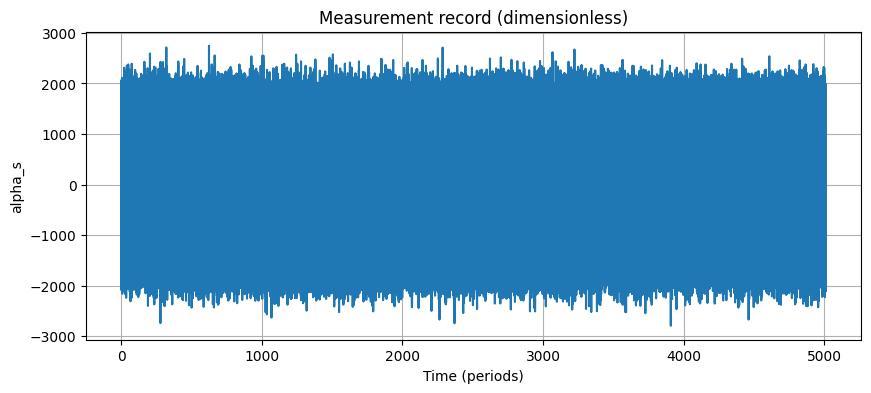

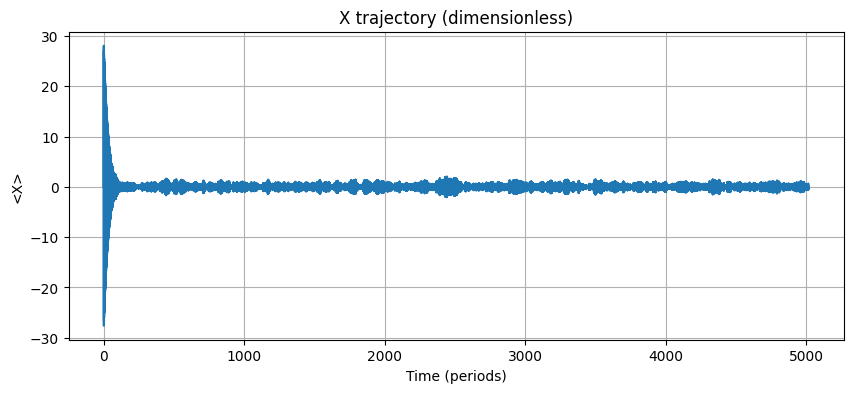

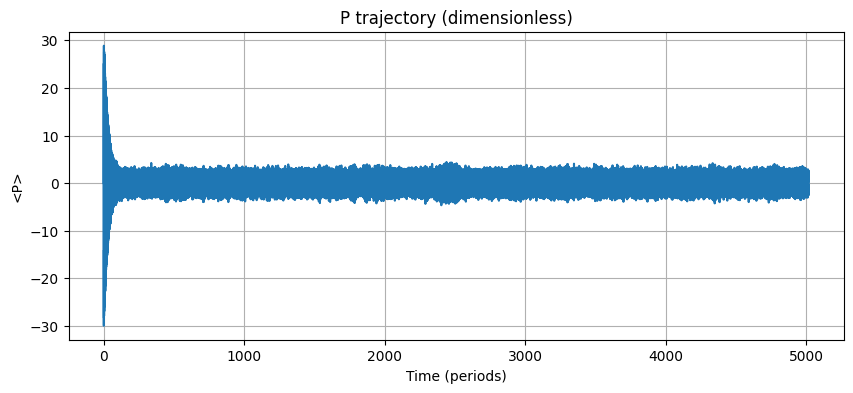

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

hbar = 1.0
m = 1.0
omega0 = 1.0
x0 = np.sqrt(hbar / (m * omega0))
p0 = np.sqrt(hbar * m * omega0)
t0 = 1 / omega0

eta = 1.0
kappa = 1e-3
#Q = omega0 / gammafb
# feedback
gamma_fb = 1e-2
#gamma_fb = 0
dt_prime = 0.0005
n_steps = int(6.3e7)
window = 50 


@njit
def run_sim(n_steps, dt_prime, gamma_fb, eta, kappa):

    # Initial conditions
    X = 20.0
    P = 20.0
    VX = 1.0
    VP = 1.0
    CXP = 0.0


    root_8ek = np.sqrt(8.0 * eta * kappa)
    sqrt_dt  = np.sqrt(dt_prime)

    # Storage
    X_traj          = np.zeros(n_steps)
    P_traj          = np.zeros(n_steps)
    VX_traj         = np.zeros(n_steps)
    VP_traj         = np.zeros(n_steps)
    CXP_traj        = np.zeros(n_steps)
    X2_traj         = np.zeros(n_steps)
    alpha_s_history = np.zeros(n_steps)

    for i in range(n_steps - 1):

        dW = np.random.randn() * sqrt_dt


        X += P * dt_prime + root_8ek * VX * dW
        alpha_s = X + dW / (root_8ek * dt_prime)
        alpha_s_history[i+1] = alpha_s
        
        if i > window:
            adot = (alpha_s_history[i] - alpha_s_history[i - window]) / (window * dt_prime)
            x_c = -gamma_fb* adot 
        
        P += -(X - x_c) * dt_prime + root_8ek * CXP * dW
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt_prime
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt_prime
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt_prime

        X2 = X**2 + VX

        X_traj[i+1]          = X
        P_traj[i+1]          = P
        VX_traj[i+1]         = VX
        VP_traj[i+1]         = VP
        CXP_traj[i+1]        = CXP
        X2_traj[i+1]         = X2


    return X_traj, P_traj, VX_traj, VP_traj, CXP_traj, X2_traj, alpha_s_history


out = run_sim(n_steps, dt_prime, gamma_fb, eta, kappa)
X_traj, P_traj, VX_traj, VP_traj, CXP_traj, X2_traj, alpha_s_history = out

time = np.arange(n_steps) * dt_prime
time_periods = time / (2 * np.pi)

plt.figure(figsize=(10, 4))
plt.plot(time_periods, alpha_s_history)
plt.title("Measurement record (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("alpha_s")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_periods, X_traj)
plt.title("X trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<X>")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_periods, P_traj)
plt.title("P trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<P>")
plt.grid(True)
plt.show()

Before was doing $F_{trap} = -k(x-x_c)$ set equal to $F_{fb} = -\gamma * x$ equal to eachother when you really want total force to be $F = F_{trap} + F_{fb}$  not just $F_{trap}$ with an $x_c$


So now doing $F_{total} = -k(X-x_c) -\gamma * X$
so $x_c$ is $= -\gamma * X$


Currently moving faster than repsnse time of oscillator 

How quickly can cool and how low temp can go 

For now look for optimal feedback gain.. if wanna minimizefinal temp what's optimal gain? and what is minumum temp

Stars mar 3

/var/folders/pg/vxw1kc2j4msgjcv3j7s6ws940000gn/T/ipykernel_13089/2557528797.py:64: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  var_x = simps(Pxx, f)


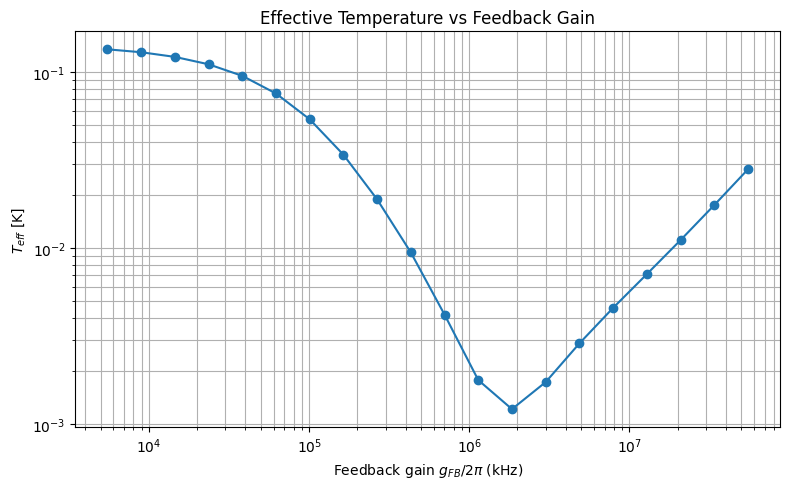

In [20]:
import numpy as np
from scipy.signal import welch 
from scipy.integrate import simps
import matplotlib.pyplot as plt
from numba import njit

eta = 1.0
kappa = 1e-3
window = 20
n_steps = int(2.5e6)
dt = 0.05
omega0 = 55e3
hbar = 6.62607015e-34 / (2 * np.pi)
kB = 1.380649e-23
T0 = hbar * omega0 / kB
root_8ek = np.sqrt(eta * 8 * kappa)
dt_prime = 0.0005

@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt_prime, eta, kappa, window):
    X = 20.0
    P = 20.0
    VX = 1.0
    VP = 1.0
    CXP = 0.0

    X_traj = np.zeros(n_steps)
    alpha_s_history = np.zeros(n_steps + 1)
    root_term = np.sqrt(8.0 * eta * kappa)
    x_c = 0.0

    for i in range(n_steps):
        dW = dW_all[i]

        X += P * dt_prime + root_term * VX * dW

        alpha_s = X + dW / (root_term * dt_prime) if (root_term * dt_prime) != 0.0 else X
        alpha_s_history[i + 1] = alpha_s  #agaisnt div by 0

        if i > window:
            adot = (alpha_s_history[i] - alpha_s_history[i - window]) / (window * dt_prime)
            x_c = -g_fb * adot

        P   += -(X - x_c) * dt_prime + root_term * CXP * dW
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt_prime
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt_prime
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt_prime

        X_traj[i] = X

    return X_traj


# Simulate multiple feedback gains
gammas = np.logspace(-4, 0, 20)
dW_all = np.random.randn(n_steps) * np.sqrt(dt_prime)
T_list = []

for g_fb in gammas:
    X_traj = simulate_trajectory(g_fb, dW_all, n_steps, dt_prime, eta, kappa, window)

    fs = 1.0 / dt
    f, Pxx = welch(X_traj, fs=fs, nperseg=len(X_traj) // 4)
    var_x = simps(Pxx, f)
    T_list.append(var_x * T0 * 1e3)


omega_m = 2 * np.pi * 55e3
gamma_FB = gammas * omega_m
g_pap = gamma_FB / (2 * np.pi) * 1e3  # kHz

plt.figure(figsize=(8, 5))
plt.loglog(g_pap, T_list, 'o-')
plt.xlabel("Feedback gain $g_{FB} / 2\\pi$ (kHz)")
plt.ylabel("$T_{eff}$ [K]")
plt.title("Effective Temperature vs Feedback Gain")
plt.grid(True, which='both')
plt.tight_layout()
plt.show()

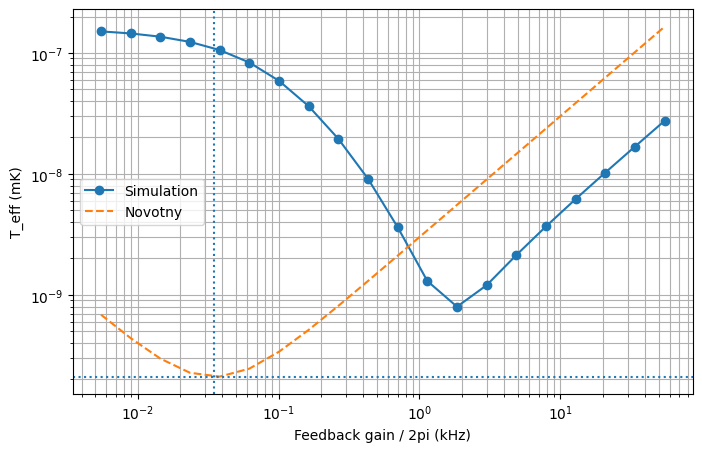

In [16]:
import numpy as np
#from paper
# Snn = dt * VX2

# Snn = 1 / VX2
#vertical shift
Snn = (1/(8*eta*kappa))#measurement noise (imprecision noise) alpha
Sff = (1 / (eta)) * (1/((4 * np.pi)**2 * Snn))
#finding Snn using relation between Snn and Sff given imprecision product did not work lol 
T_theory = []
for g_fb in gammas:
    T = np.pi*(Sff/g_fb + g_fb*Snn)*T0 /1e3
    T_theory.append(T)

T_min = 2*np.pi*np.sqrt(Sff*Snn)*T0 /1e3
g_opt = np.sqrt(Sff/Snn) 

#converting gain of paper to units
omega_m = 2*np.pi*55e3
g_pap = gammas*omega_m/(2*np.pi)/1e3


plt.figure(figsize=(8,5))
plt.loglog(g_pap, T_list, 'o-', label='Simulation')
plt.loglog(g_pap, T_theory, '--', label='Novotny')
plt.axhline(T_min, linestyle=':')
plt.axvline(g_opt*omega_m/(2*np.pi)/1e3, linestyle=':')
plt.xlabel("Feedback gain / 2pi (kHz)")
plt.ylabel("T_eff (mK)")
plt.legend()
plt.grid(True, which='both')
plt.show()

Now looping over differnt kappas:

/var/folders/pg/vxw1kc2j4msgjcv3j7s6ws940000gn/T/ipykernel_13089/2074134354.py:68: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  var_x  = simps(Pxx, f)


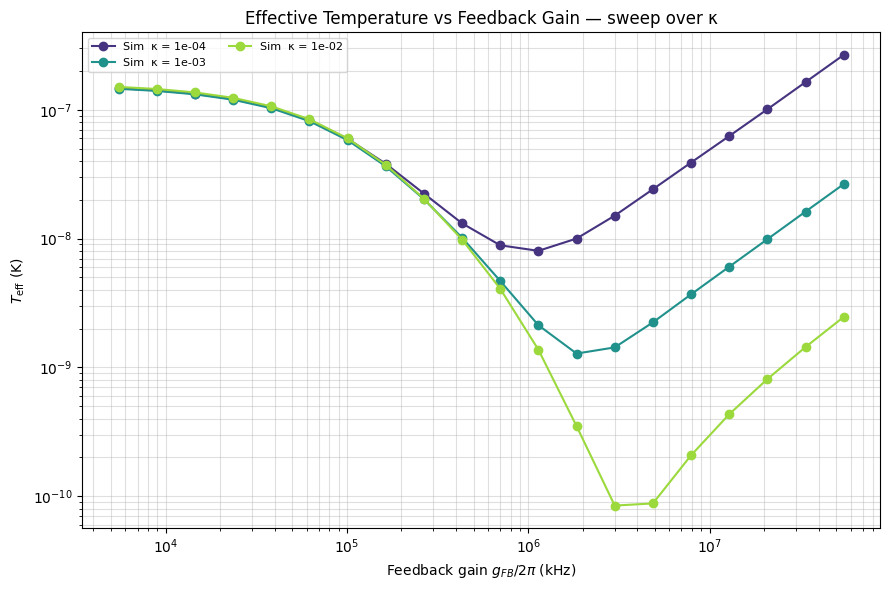

In [23]:
import numpy as np
from scipy.signal import welch
from scipy.integrate import simps
import matplotlib.pyplot as plt
from numba import njit

eta   = 1.0
window  = 20
n_steps = int(2.5e6)
dt      = 0.05
omega0  = 55e3
hbar    = 6.62607015e-34 / (2 * np.pi)
kB      = 1.380649e-23
T0      = hbar * omega0 / kB #try unit conversion that includes mass cuz epect min to be 1/2mw
dt_prime = 0.0005

@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt_prime, eta, kappa, window):
    X, P   = 20.0, 20.0
    VX, VP = 1.0,  1.0
    CXP    = 0.0

    X_traj          = np.zeros(n_steps)
    alpha_s_history = np.zeros(n_steps + 1)
    root_term       = np.sqrt(8.0 * eta * kappa)
    x_c             = 0.0

    for i in range(n_steps):
        dW = dW_all[i]

        X += P * dt_prime + root_term * VX * dW
        alpha_s = X + dW / (root_term * dt_prime) if (root_term * dt_prime) != 0.0 else X
        alpha_s_history[i + 1] = alpha_s

        if i > window:
            adot = (alpha_s_history[i] - alpha_s_history[i - window]) / (window * dt_prime)
            x_c  = -g_fb * adot

        P   += -(X - x_c) * dt_prime + root_term * CXP * dW
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt_prime
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt_prime
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt_prime

        X_traj[i] = X

    return X_traj


gammas = np.logspace(-4, 0, 20)
kappas = [1e-4, 1e-3, 1e-2]          # sweep over measurement rates
dW_all = np.random.randn(n_steps) * np.sqrt(dt_prime)   # shared noise realization

omega_m = 2 * np.pi * omega0
g_pap   = gammas * omega_m / (2 * np.pi) * 1e3          # kHz axis

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(kappas)))

fig, ax = plt.subplots(figsize=(9, 6))

for color, kappa in zip(colors, kappas):

    # ── simulation ──────────────────────────────────────────────────────────
    T_list = []
    for g_fb in gammas:
        X_traj = simulate_trajectory(g_fb, dW_all, n_steps, dt_prime, eta, kappa, window)
        fs     = 1.0 / dt
        f, Pxx = welch(X_traj, fs=fs, nperseg=len(X_traj) // 4)
        var_x  = simps(Pxx, f)
        T_list.append(var_x * T0 / 1e3)

    # ── theory (Novotný) ─────────────────────────────────────────────────────
    Snn = (1/(8*eta*kappa))#measurement noise (imprecision noise) alpha
    Sff = (1 / (eta)) * (1/((4 * np.pi)**2 * Snn))
    T_theory = [np.pi * (Sff / g + g * Snn) * T0  for g in gammas]
    T_min    = 2 * np.pi * np.sqrt(Sff * Snn) * T0 
    g_opt    = np.sqrt(Sff / Snn) * omega_m / (2 * np.pi)   # kHz

    label = f"κ = {kappa:.0e}"
    ax.loglog(g_pap, T_list,   'o-',  color=color, label=f"Sim  {label}")
    # ax.loglog(g_pap, T_theory, '--',  color=color, label=f"Theory {label}")
    # ax.axhline(T_min,  color=color, linestyle=':',  linewidth=0.8)
    # ax.axvline(g_opt,  color=color, linestyle=':',  linewidth=0.8)

ax.set_xlabel(r"Feedback gain $g_{FB}/2\pi$ (kHz)")
ax.set_ylabel(r"$T_\mathrm{eff}$ (K)")
ax.set_title("Effective Temperature vs Feedback Gain — sweep over κ")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, which='both', alpha=0.4)
fig.tight_layout()
plt.show()

Plot the psds and set axis lines for the limits of integration... amke sure imprecision noise is included

and upload to git hub


use more relaistic value sof eta like .1 and see how it changes things

unit vcovnersion to temp with mass to geet 1/2mw

make seperate branch 


End mar 3

<x> looked like a rnaodm walk so now i am trying to see what it looks like for no geedback... because intial condiitons fo <x> and <p> are 10 abut the <x> is going all the way to 175 so there must be something wrong wiht the measuement feedback ..

THIS

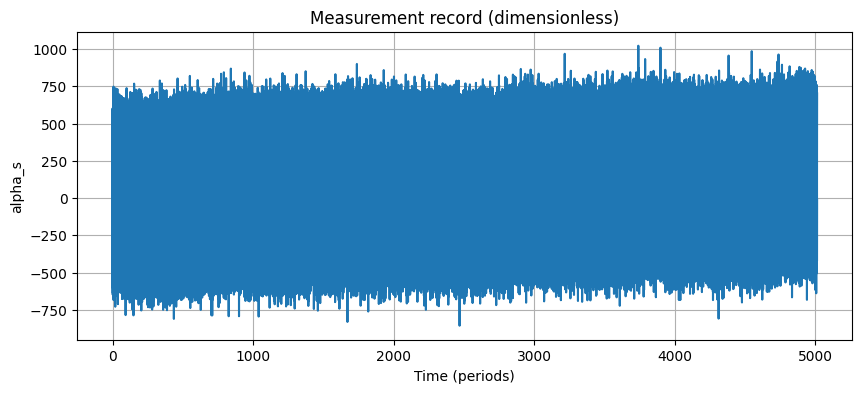

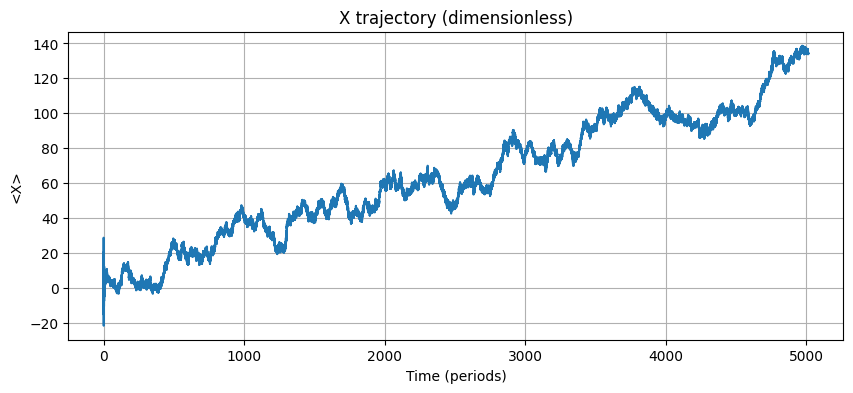

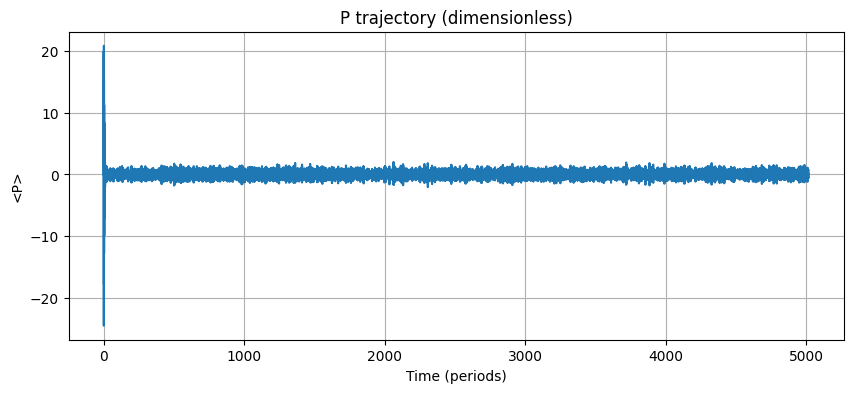

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

hbar = 1.0
m = 1.0
omega0 = 1.0
x0 = np.sqrt(hbar / (m * omega0))
p0 = np.sqrt(hbar * m * omega0)
t0 = 1 / omega0

gamma_sc = 0.01
eta = 1.0
kappa = 1e-2
#Q = omega0 / gammafb
# feedback
# gamma_fb = 1e-2
gamma_fb = 1/100
tau_filter = 10 #time cosntant.. takes x_filter 10 * time = 10 * 1/omega0 about 1.5 oscialltion periods 
#x filter ^ takes 1.5 oscialltion periods to catch up to true position
#too fast and it's too noisy... too slow and it doesn't catch up to true position
#omega_0 = 1, period = 2pi so tau is like about 1.5 oscialltion periods so we're good?
dt_prime = 0.0005
n_steps = int(6.3e7)
window = 50 

@njit
def run_sim(n_steps, dt_prime, gamma_fb, tau_filter, eta, kappa):

    # Initial conditions
    X = 20.0
    P = 20.0
    VX = 1.0
    VP = 1.0
    CXP = 0.0

    # Filter states — OUTSIDE the loop so they accumulate across steps
    x_filtered = 0.0

    root_8ek = np.sqrt(8.0 * eta * kappa)
    sqrt_dt  = np.sqrt(dt_prime)

    # Storage
    X_traj = np.zeros(n_steps)
    P_traj = np.zeros(n_steps)
    VX_traj = np.zeros(n_steps)
    VP_traj = np.zeros(n_steps)
    CXP_traj = np.zeros(n_steps)
    X2_traj = np.zeros(n_steps)
    alpha_s_history = np.zeros(n_steps)
    x_c = 0.0
    x_filtered = 0.0
    for i in range(n_steps - 1):

        dW = np.random.randn() * sqrt_dt

        # how far is current reading from long run average 
        #position update: og position + fraction of gap (fraction set by tau filter)
        #dx_filtered/dt = (alpha_s - x_filtered) / tau_filter 
        #noise has power across all time scales in psd but the rela signal only really spikes at omega 
        #etween the oscillation peak and the noise floor.,,filter 
        #cutoff frequency 1/tau_filter should be just below omega0  slow enough to average out the flat 
        #noise floor but fast enough to still pass the oscillation peak.
        # x_filtered += (alpha_s - x_filtered) * dt_prime / tau_filter

        #velocity-like signal
        #rate of change of the filtered position estimate, scaled by tau_filter.
        #alpha_s is position rn and x_fiteres is position averages overlast tau filter time units (1.5 oscialltion periods)
        # v_estimate = alpha_s - x_filtered
        # use x_c from PREVIOUS timestep in the force
        X += P * dt_prime + root_8ek * VX * dW
        P += -(X - x_c) * dt_prime + root_8ek * CXP * dW #something wierd is happenig here i guess idk 
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt_prime
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt_prime
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt_prime

        # now measure and compute x_c for NEXT timestep
        alpha_s = X + dW / (root_8ek * dt_prime)
        alpha_s_history[i+1] = alpha_s #what

        x_filtered_prev = x_filtered
        if i > window:
            x_filtered += (alpha_s_history[i] - x_filtered) * dt_prime / tau_filter
            v_estimate = (x_filtered - x_filtered_prev) / dt_prime
            x_c = x_filtered + gamma_fb * v_estimate  # will be used next iteration

        
        X2 = X**2 + VX

        X_traj[i+1]          = X
        P_traj[i+1]          = P
        VX_traj[i+1]         = VX
        VP_traj[i+1]         = VP
        CXP_traj[i+1]        = CXP
        X2_traj[i+1]         = X2


    return X_traj, P_traj, VX_traj, VP_traj, CXP_traj, X2_traj, alpha_s_history, helpme


out = run_sim(n_steps, dt_prime, gamma_fb, tau_filter, eta, kappa)
X_traj, P_traj, VX_traj, VP_traj, CXP_traj, X2_traj, alpha_s_history, helpme = out

time = np.arange(n_steps) * dt_prime
time_periods = time / (2 * np.pi)

plt.figure(figsize=(10, 4))
plt.plot(time_periods, alpha_s_history)
plt.title("Measurement record (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("alpha_s")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_periods, X_traj)
plt.title("X trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<X>")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_periods, P_traj)
plt.title("P trajectory (dimensionless)")
plt.xlabel("Time (periods)")
plt.ylabel("<P>")
plt.grid(True)
plt.show()

THIS OLD

/var/folders/pg/vxw1kc2j4msgjcv3j7s6ws940000gn/T/ipykernel_30104/2898629454.py:67: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  var_x = simps(Pxx, f)


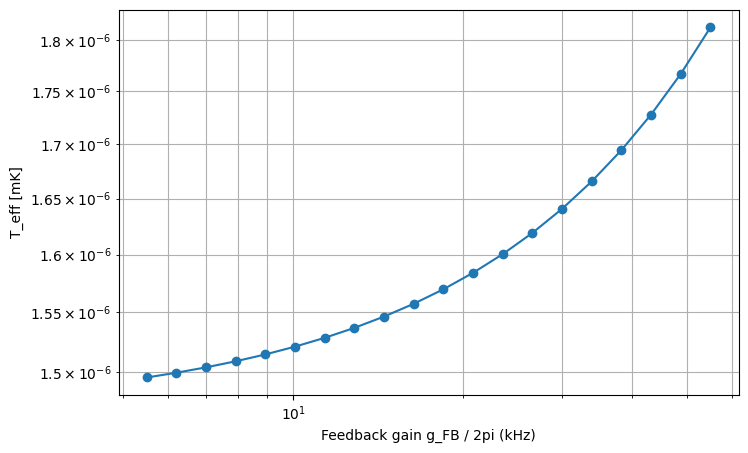

In [18]:
import numpy as np
from scipy.signal import welch 
from scipy.integrate import simps
import matplotlib.pyplot as plt
from numba import njit


eta = 1.0
kappa = 1e-3
window = 20
n_steps = int(2.5e6)
dt = 0.05
omega0 = 55e3# rad / sec x mode
hbar = 6.62607015e-34 / (2* np.pi) #m^2 kg / s
omega_z = omega0
kB = 1.380649e-23
T0 = hbar * (omega0) / kB

@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, tau_filter, window):
    X = 20.0
    P = 20.0
    VX = 1.0
    VP = 1.0
    CXP = 0.0

    X_traj = np.zeros(n_steps)
    root_term = np.sqrt(8.0 * eta * kappa)
    x_c = 0.0
    x_filtered = 0.0

    for i in range(n_steps):
        dW = dW_all[i]

        X += P * dt + root_term * VX * dW
        P += -(X - x_c) * dt + root_term * CXP * dW

        alpha_s = X + dW / (root_term * dt)

        x_filtered_prev = x_filtered
        x_filtered += (alpha_s - x_filtered) * dt / tau_filter
        v_estimate = (x_filtered - x_filtered_prev) / dt

        if i > window:
            x_c = x_filtered + g_fb * v_estimate
        else:
            x_c = 0.0

        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt

        X_traj[i] = X

    return X_traj


# Simulate multiple feedback gains
gammas = np.logspace(-1, 0, 20)
dW_all = np.random.randn(n_steps) * np.sqrt(dt)
T_list = []
for g_fb in gammas:
    X_traj = simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, tau_filter, window)
    
    fs = 1.0 / dt
    f, Pxx = welch(X_traj, fs=fs, nperseg=len(X_traj)//4)
    var_x = simps(Pxx, f)
    T_list.append(var_x * T0 / 1e3)
#put in units for plotting
omega_m = 2*np.pi*55e3
gamma_FB = gammas * omega_m
g_pap = gamma_FB / (2*np.pi) / 1e3 #g paper

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.loglog(g_pap, T_list, 'o-')
plt.xlabel("Feedback gain g_FB / 2pi (kHz)")
plt.ylabel("T_eff [mK]")
plt.grid(True, which='both')
plt.show()


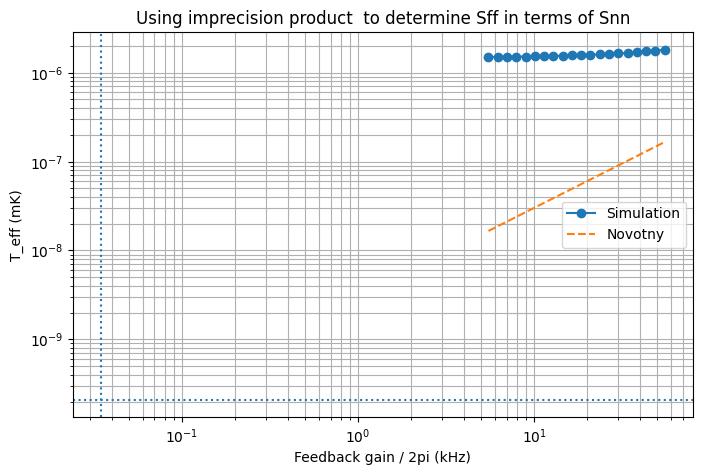

In [19]:
#from paper
# Snn = 1/(8*eta*kappa) #measurement noise (imprecision noise) alpha
#finding Snn using relation between Snn and Sff given imprecision product
# Sff = 8*eta*kappa*np.mean(VX2_list) #fluctuating force (measurement backaction,) from x
# Snn = (1/(Sff * eta))*(hbar/(4*np.pi))**2


Snn = 1 / (8 * eta * kappa) + np.mean(VX2_list) * (8 * eta * kappa +2)
Sff = (1 / (eta)) * (1/((4 * np.pi)**2 * Snn))
#finding Snn using relation between Snn and Sff given imprecision product did not work lol 
T_theory = []
for g_fb in gammas:
    T = np.pi*(Sff/g_fb + g_fb*Snn)*T0 / 1e3
    T_theory.append(T)

T_min = 2*np.pi*np.sqrt(Sff*Snn)*T0 / 1e3
g_opt = np.sqrt(Sff/Snn)

#converting gain of paper to units
omega_m = 2*np.pi*55e3
# g_pap = gammas*omega_m/(2*np.pi)/1e3
g_pap = gammas * omega_m / (2*np.pi) / 1e3




plt.figure(figsize=(8,5))
plt.loglog(g_pap, T_list, 'o-', label='Simulation')
plt.loglog(g_pap, T_theory, '--', label='Novotny')
plt.axhline(T_min, linestyle=':')
plt.axvline(g_opt*omega_m/(2*np.pi)/1e3, linestyle=':')
plt.xlabel("Feedback gain / 2pi (kHz)")
plt.title("Using imprecision product  to determine Sff in terms of Snn")
plt.ylabel("T_eff (mK)")
plt.legend()
plt.grid(True, which='both')
plt.show()

/var/folders/pg/vxw1kc2j4msgjcv3j7s6ws940000gn/T/ipykernel_98735/2711253097.py:85: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  var_X   = simps(Pxx, f)


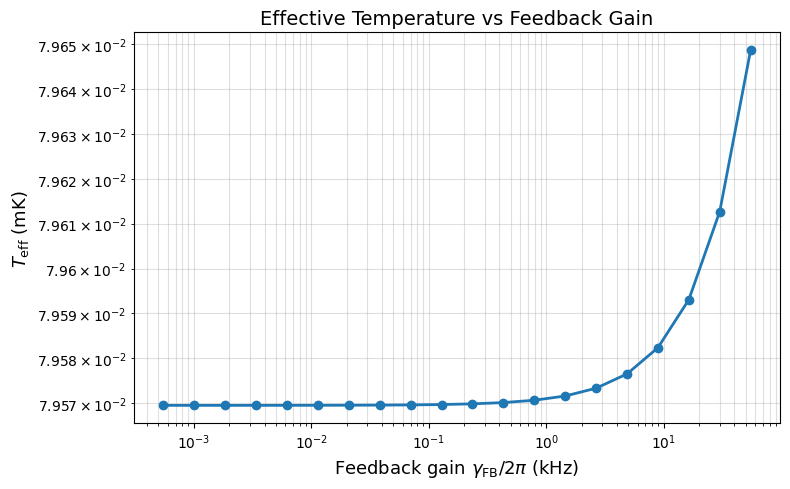

In [27]:
import numpy as np
from scipy.signal import welch
from scipy.integrate import simps
import matplotlib.pyplot as plt
from numba import njit

# ── Physical constants ────────────────────────────────────────────────────────
hbar   = 6.62607015e-34 / (2 * np.pi)
kB     = 1.380649e-23

# ── Parameters ────────────────────────────────────────────────────────────────
eta        = 1.0
kappa      = 1e-3
omega0     = 55e3      
T0         = hbar * omega0 / kB

n_steps    = int(2.5e6)
dt         = 0.005          # dimensionless timestep (units of 1/omega0)
tau_filter = 10.0          # IIR filter time constant (sim units)
window     = 20            # feedback warmup steps

# ── Simulation ────────────────────────────────────────────────────────────────
@njit
def simulate_trajectory(g_fb, dW_all, n_steps, dt, eta, kappa, tau_filter, window):
    X   = 10.0
    P   = 10.0
    VX  = 1.0
    VP  = 1.0
    CXP = 0.0

    x_filtered = 0.0
    root_term  = np.sqrt(8.0 * eta * kappa)

    X_traj  = np.zeros(n_steps)
    VX_traj = np.zeros(n_steps)

    for i in range(n_steps):
        dW = dW_all[i]

        # Measurement
        alpha_s = X + dW / (root_term * dt)

        # IIR filter
        x_filtered_prev = x_filtered
        x_filtered     += (alpha_s - x_filtered) * dt / tau_filter
        v_estimate      = x_filtered - x_filtered_prev

        # Feedback (with warmup)
        if i > window:
            x_c = x_filtered + g_fb * v_estimate
        else:
            x_c = 0.0

        # Equations of motion
        X   +=  P * dt + root_term * VX * dW
        P   += -(X - x_c) * dt + root_term * CXP * dW
        VX  += (2.0 * CXP - 8.0 * eta * kappa * VX**2) * dt
        VP  += (-2.0 * CXP + 2.0 * kappa - 8.0 * eta * kappa * CXP**2) * dt
        CXP += (VP - VX - 8.0 * eta * kappa * VX * CXP) * dt

        X_traj[i]  = X
        VX_traj[i] = VX

    return X_traj, VX_traj


# ── Sweep feedback gain ───────────────────────────────────────────────────────
gammas = np.logspace(-5, 0, 20)
dW_all = np.random.randn(n_steps) * np.sqrt(dt)
T_list = []

for g_fb in gammas:
    X_traj, VX_traj = simulate_trajectory(
        g_fb, dW_all, n_steps, dt, eta, kappa, tau_filter, window
    )

    # Discard transient
    X_ss  = X_traj[n_steps // 2:]
    VX_ss = VX_traj[n_steps // 2:]

    # Variance of conditional mean via Welch
    X_ss_centered = X_ss - np.mean(X_ss)
    fs = 1.0 / dt
    f, Pxx  = welch(X_ss_centered, fs=fs, nperseg=len(X_ss) // 4)
    var_X   = simps(Pxx, f)

    # Total variance = trajectory variance + mean Kalman uncertainty
    var_total = var_X + np.mean(VX_ss)

    # Phonon number and effective temperature
    n_bar = max(var_total - 0.5, 1e-6)
    T_eff = hbar * omega0 / (kB * np.log(1.0 + 1.0 / n_bar))
    T_list.append(T_eff * 1e3)   # mK

# ── Convert gain to physical units for plot ───────────────────────────────────
omega_m  = 2 * np.pi * omega0
gamma_FB = gammas * omega_m
g_pap    = gamma_FB / (2 * np.pi) / 1e3   # kHz

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.loglog(g_pap, T_list, 'o-', linewidth=2, markersize=6)
plt.xlabel(r"Feedback gain $\gamma_{\rm FB} / 2\pi$ (kHz)", fontsize=13)
plt.ylabel(r"$T_{\rm eff}$ (mK)", fontsize=13)
plt.title("Effective Temperature vs Feedback Gain", fontsize=14)
plt.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()

/var/folders/pg/vxw1kc2j4msgjcv3j7s6ws940000gn/T/ipykernel_98735/1695255251.py:37: DeprecationWarning: 'scipy.integrate.simps' is deprecated in favour of 'scipy.integrate.simpson' and will be removed in SciPy 1.14.0
  var_x = simps(Pxx, f)   # <X^2> in dimensionless units


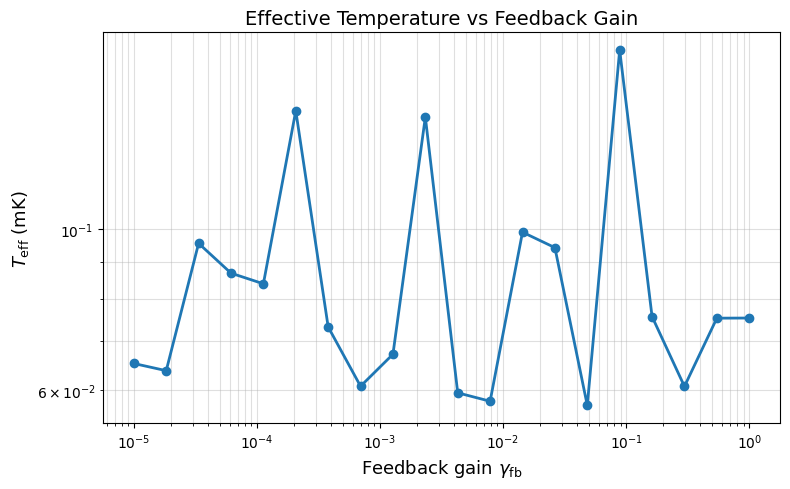

In [20]:
import numpy as np
from scipy.signal import welch
from scipy.integrate import simps
import matplotlib.pyplot as plt
from numba import njit

# ── Physical constants ────────────────────────────────────────────────────────
hbar = 6.62607015e-34 / (2 * np.pi)
kB   = 1.380649e-23

# ── Parameters ────────────────────────────────────────────────────────────────
eta        = 1.0
kappa      = 1e-3
omega0     = 55e3          # rad/s
T0         = hbar * omega0 / kB   # quantum of temperature ~ 4e-7 K for 55 kHz

n_steps    = int(2.5e6)
dt         = 0.005         # dimensionless timestep (units of 1/omega0)
tau_filter = 10.0          # IIR filter time constant (sim units)
window     = 20           # feedback warmup steps


# ── Sweep feedback gain ───────────────────────────────────────────────────────
gammas = np.logspace(-5, 0, 20)
T_list = []

for g_fb in gammas:
    np.random.seed(42)
    helpme = simulate_trajectory(g_fb, n_steps, dt, eta, kappa, tau_filter, window)

    # Discard first half (transient)
    X_ss = helpme[n_steps // 2:]

    # PSD -> variance via Welch
    fs = 1.0 / dt
    f, Pxx = welch(X_ss, fs=fs, nperseg=len(X_ss) // 4)
    var_x = simps(Pxx, f)   # <X^2> in dimensionless units

    # Convert variance to phonon number then to temperature
    # In dimensionless units: <X^2> = n_bar + 0.5  (zero-point = 0.5)
    n_bar = max(var_x - 0.5, 1e-6)   # clamp to avoid log(0)
    T_eff = hbar * omega0 / (kB * np.log(1.0 + 1.0 / n_bar))
    T_eff_mK = T_eff * 1e3
    T_list.append(T_eff_mK)


# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.loglog(gammas, T_list, 'o-', linewidth=2, markersize=6)
plt.xlabel(r"Feedback gain $\gamma_{\rm fb}$", fontsize=13)
plt.ylabel(r"$T_{\rm eff}$ (mK)", fontsize=13)
plt.title("Effective Temperature vs Feedback Gain", fontsize=14)
plt.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()

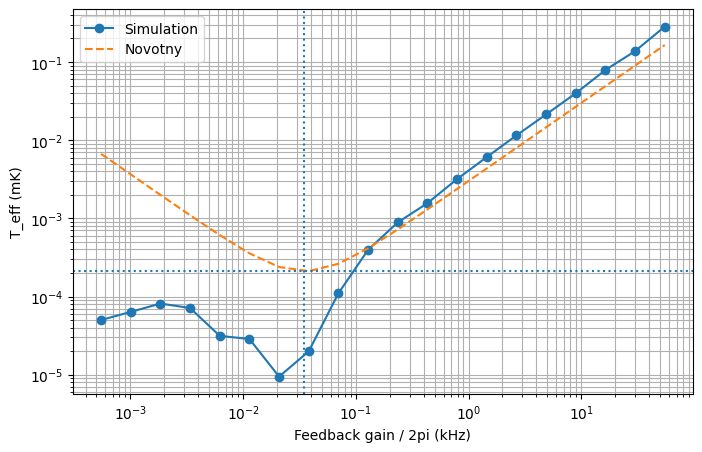

In [48]:
import numpy as np
#from paper
# Snn = dt * VX2

# Snn = 1 / VX2
#vertical shift
Snn = (1/(8*eta*kappa))#measurement noise (imprecision noise) alpha
Sff = (1 / (eta)) * (1/((4 * np.pi)**2 * Snn))
#finding Snn using relation between Snn and Sff given imprecision product did not work lol 
T_theory = []
for g_fb in gammas:
    T = np.pi*(Sff/g_fb + g_fb*Snn)*T0*1e3
    T_theory.append(T)

T_min = 2*np.pi*np.sqrt(Sff*Snn)*T0*1e3
g_opt = np.sqrt(Sff/Snn)

#converting gain of paper to units
omega_m = 2*np.pi*55e3
g_pap = gammas*omega_m/(2*np.pi)/1e3


plt.figure(figsize=(8,5))
plt.loglog(g_pap, T_list, 'o-', label='Simulation')
plt.loglog(g_pap, T_theory, '--', label='Novotny')
plt.axhline(T_min, linestyle=':')
plt.axvline(g_opt*omega_m/(2*np.pi)/1e3, linestyle=':')
plt.xlabel("Feedback gain / 2pi (kHz)")
plt.ylabel("T_eff (mK)")
plt.legend()
plt.grid(True, which='both')
plt.show()

In [57]:
g_opt

0.0006366197723675814

In [49]:
gammas

array([1.00000000e-05, 1.83298071e-05, 3.35981829e-05, 6.15848211e-05,
       1.12883789e-04, 2.06913808e-04, 3.79269019e-04, 6.95192796e-04,
       1.27427499e-03, 2.33572147e-03, 4.28133240e-03, 7.84759970e-03,
       1.43844989e-02, 2.63665090e-02, 4.83293024e-02, 8.85866790e-02,
       1.62377674e-01, 2.97635144e-01, 5.45559478e-01, 1.00000000e+00])

In [50]:
g_pap

array([5.50000000e-04, 1.00813939e-03, 1.84790006e-03, 3.38716516e-03,
       6.20860840e-03, 1.13802594e-02, 2.08597960e-02, 3.82356038e-02,
       7.00851242e-02, 1.28464681e-01, 2.35473282e-01, 4.31617984e-01,
       7.91147439e-01, 1.45015799e+00, 2.65811163e+00, 4.87226735e+00,
       8.93077207e+00, 1.63699329e+01, 3.00057713e+01, 5.50000000e+01])